Total unique images: 182


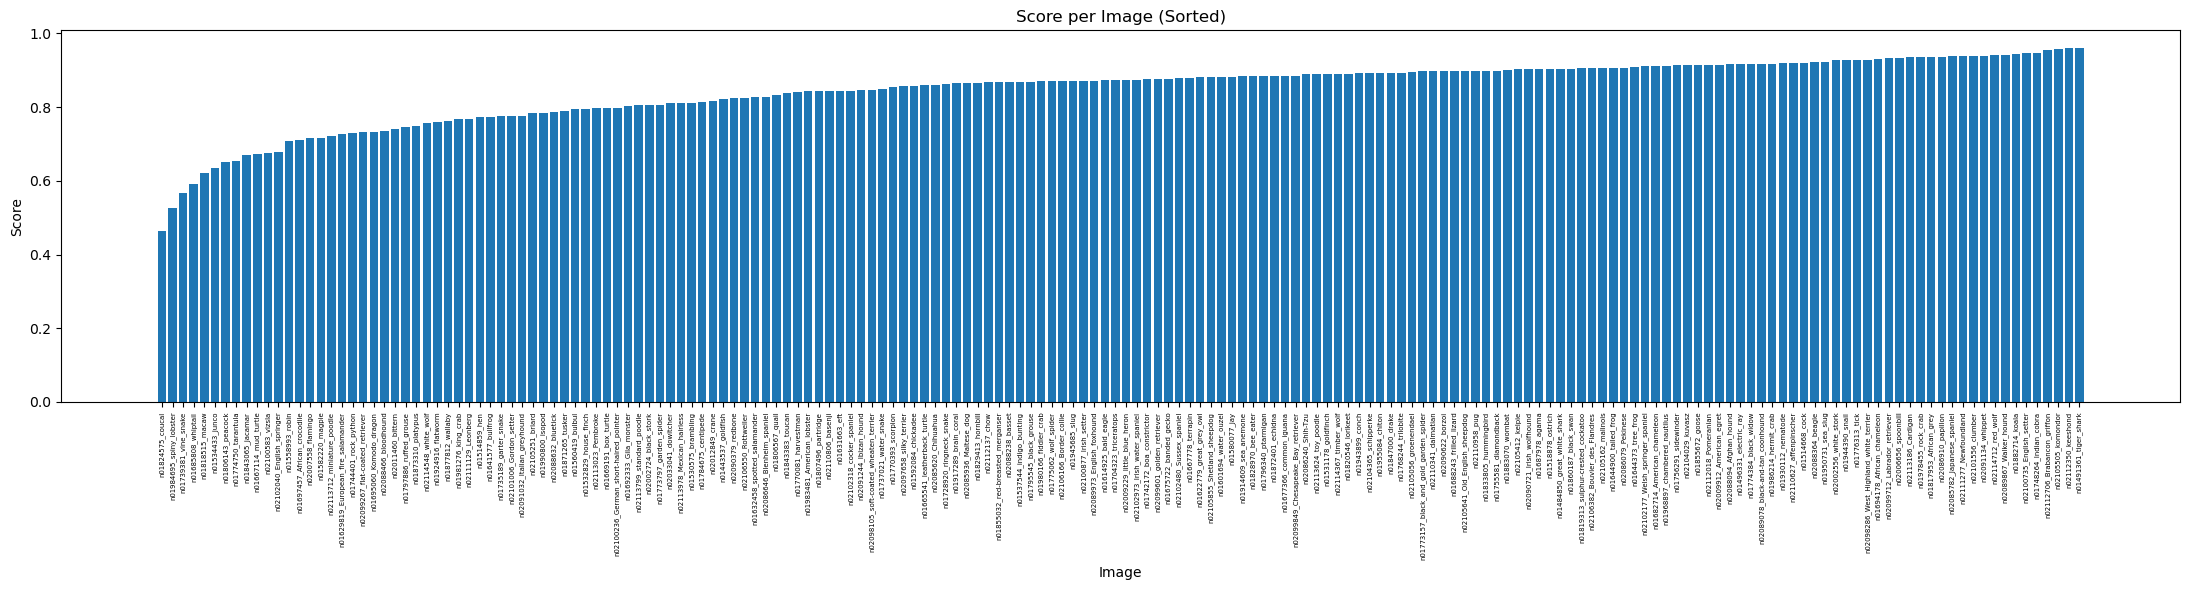

<Figure size 640x480 with 0 Axes>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Load CSV
# ===============================
file_path = "csvs/ALL_vggnet_triplets_merged.csv"  # adjust path if needed
df = pd.read_csv(file_path)

# ===============================
# Select columns
# ===============================
image_col = "image"
score_col = "score"

# Remove missing values
df = df[[image_col, score_col]].dropna()

# Ensure image names are strings
df[image_col] = df[image_col].astype(str)

# Keep only one row per unique image
df_unique = df.drop_duplicates(subset=image_col)

# Sort by score (ascending)
df_sorted = df_unique.sort_values(by=score_col, ascending=True)

print("Total unique images:", len(df_sorted))

# ===============================
# Create bar plot
# ===============================
x = np.arange(len(df_sorted))

plt.figure(figsize=(22, 6))
plt.bar(x, df_sorted[score_col].values)

plt.xticks(x, df_sorted[image_col].values, rotation=90, fontsize=5)
plt.ylabel("Score")
plt.xlabel("Image")
plt.title("Score per Image (Sorted)")
plt.tight_layout()

plt.show()

# ===============================
# Optional: Save as PDF
# ===============================
plt.savefig("score_per_image_sorted.pdf")

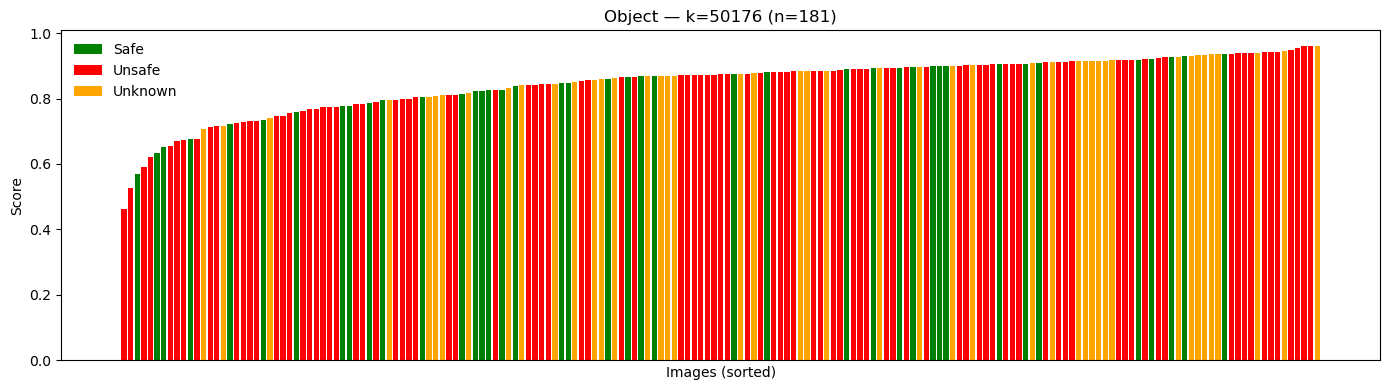

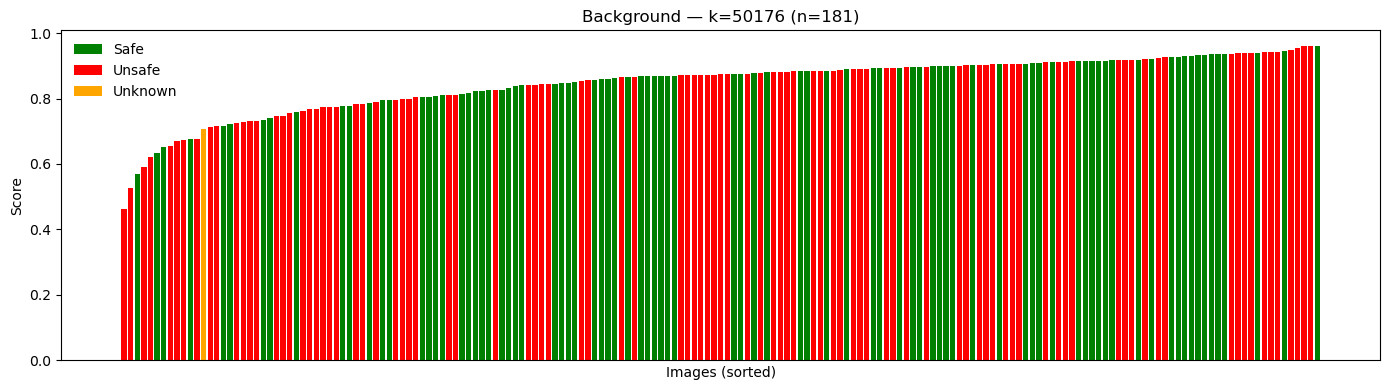

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ===============================
# Load
# ===============================
df = pd.read_csv("csvs/ALL_vggnet_triplets_merged.csv")

# ===============================
# Build semantic properly
# ===============================
tag_to_semantic = {
    "global": "Global",
    "fix_nonmask": "Object",
    "fix_mask": "Background",
}

df["semantic"] = df["tag"].map(tag_to_semantic)

df = df.dropna(subset=["image", "result", "semantic", "score"])
df["image"] = df["image"].astype(str)

# ===============================
# Result → Color
# ===============================
def result_to_color(r):
    if r == "unsat False":
        return "green"
    elif r == "unsat True":
        return "green"
    
    elif r == "sat True":
        return "red"
    
    elif r == "sat False":
        return "red"
    
    elif r == "timeout False":
        return "orange"
    return "orange"

df["color"] = df["result"].apply(result_to_color)

# ===============================
# Plot per semantic and per k (correctly)
# ===============================
sem_order = ["Global", "Object", "Background"]

for sem in sem_order:

    df_sem = df[df["semantic"] == sem]

    if df_sem.empty:
        continue

    # k_values = sorted(df_sem["k"].unique())
    k_values = [50176]

    for k_val in k_values:

        d = df_sem[df_sem["k"] == k_val].copy()

        if d.empty:
            continue

        d = d.sort_values("score", ascending=True)
        d = d.drop_duplicates(subset="image", keep="first")

        x = np.arange(len(d))

        plt.figure(figsize=(14,4))
        plt.bar(x, d["score"].values, color=d["color"].values)

        plt.title(f"{sem} — k={k_val} (n={len(d)})")
        plt.xlabel("Images (sorted)")
        plt.ylabel("Score")
        plt.xticks([])

        legend_handles = [
            Patch(facecolor="green", label="Safe"),
            Patch(facecolor="red", label="Unsafe"),
            Patch(facecolor="orange", label="Unknown"),
        ]
        plt.legend(handles=legend_handles, frameon=False)

        plt.tight_layout()
        plt.show()